# Day 1: Data Acquisition
This notebook downloads 5 years of daily OHLCV data for 18 stocks and the NIFTY50 index, computes log returns and rolling 10-day volatility, and saves the cleaned data to parquet files.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


## 1. Stock Universe and Configuration


In [2]:
STOCKS = {
    "financials":  ["HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS", "AXISBANK.NS"],
    "it":          ["TCS.NS", "INFY.NS", "WIPRO.NS"],
    "energy":      ["RELIANCE.NS", "ONGC.NS"],
    "auto":        ["MARUTI.NS", "TATAMOTORS.NS", "BAJAJ-AUTO.NS"],
    "consumer":    ["HINDUNILVR.NS", "NESTLEIND.NS", "ASIANPAINT.NS"],
    "pharma":      ["SUNPHARMA.NS", "DRREDDY.NS"],
    "industrial":  ["LT.NS"],
}

# Flatten the stocks list
TICKERS = [ticker for sector_stocks in STOCKS.values() for ticker in sector_stocks]
INDEX = "^NSEI"
ALL_TICKERS = TICKERS + [INDEX]

START = "2019-01-01"
END   = "2026-07-04"

print(f"Total specific stocks: {len(TICKERS)}")
print(f"Index: {INDEX}")


Total specific stocks: 18
Index: ^NSEI


## 2. Download Data via yfinance


In [14]:
# Using auto_adjust=True to get split/dividend adjusted prices
raw_data = yf.download(ALL_TICKERS, start=START, end=END, auto_adjust=True)
raw_data.head()
print(len(raw_data))

[**********            21%                       ]  4 of 19 completed$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  19 of 19 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


1355


## 3. Data Cleaning and Flattening Columns


In [4]:
# Flatten MultiIndex columns immediately
raw_data.columns = ['_'.join(col).strip() for col in raw_data.columns]

# Extract only the Close columns (which are already adjusted due to auto_adjust=True)
close_cols = [col for col in raw_data.columns if col.startswith("Close_")]
prices = raw_data[close_cols].copy()

# Rename columns to just the ticker name
prices.rename(columns=lambda x: x.replace("Close_", ""), inplace=True)
prices.head()


,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,DRREDDY.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,KOTAKBANK.NS,LT.NS,MARUTI.NS,NESTLEIND.NS,ONGC.NS,RELIANCE.NS,SUNPHARMA.NS,TATAMOTORS.NS,TCS.NS,WIPRO.NS,^NSEI
Date,,,,,,,,,,,,,,,,,,,
2019-01-01,1283.872070,623.916870,2200.992188,498.221863,496.185791,1591.314453,350.957001,541.725830,248.915359,1283.006348,7004.461426,501.669739,94.748299,496.196381,402.755920,NaN,1561.000244,112.147339,NaN
2019-01-02,1294.870850,616.705872,2173.022217,497.075226,491.658508,1576.736328,351.777130,544.984009,246.954590,1268.413574,6808.711426,502.596619,93.823151,489.733917,408.794220,NaN,1577.817871,111.769684,10792.500000
2019-01-03,1299.551392,604.671143,2180.569824,492.545959,487.800995,1580.093628,350.474609,545.065552,245.889633,1241.274414,6748.849609,510.418762,90.856277,483.691895,405.124786,NaN,1558.662476,111.752518,10672.250000
2019-01-04,1297.257935,616.258301,2207.086670,496.874542,489.106079,1574.173950,352.356079,538.467651,248.417694,1235.090454,6777.469238,494.207428,92.961815,486.303436,402.988190,NaN,1539.711670,111.392029,10727.349609
2019-01-07,1306.759033,634.012146,2146.020752,488.972351,489.845184,1577.045532,354.768097,547.142700,248.148972,1231.308838,6896.961426,491.242523,94.333580,489.003540,400.201202,NaN,1556.980469,111.323364,10771.799805


## 4. Master Trading Calendar and Missing Value Imputation


In [5]:
# Build master trading calendar (union of all non-NaN dates across all tickers)
# yf.download already aligns dates, but to be sure:
master_calendar = prices.dropna(how='all').index
prices = prices.reindex(master_calendar)

# Forward-fill at most 2 consecutive NaN days (exchange holidays)
prices = prices.ffill(limit=2)

# Drop any stock with > 5% missing rows after forward-filling
missing_pct = prices.isnull().sum() / len(prices)
print("Missing percentage per column after ffill:")
print(missing_pct)

cols_to_drop = missing_pct[missing_pct > 0.05].index
if len(cols_to_drop) > 0:
    print(f"Dropping {list(cols_to_drop)} due to >5% missing data.")
    prices.drop(columns=cols_to_drop, inplace=True)
else:
    print("No stocks dropped due to missing data.")

# Final dropna for any remaining NaNs at the very beginning of the series
prices.dropna(inplace=True)
print(f"Final shape of prices dataframe: {prices.shape}")


Missing percentage per column after ffill:
ASIANPAINT.NS    0.000000
AXISBANK.NS      0.000000
BAJAJ-AUTO.NS    0.000000
DRREDDY.NS       0.000000
HDFCBANK.NS      0.000000
HINDUNILVR.NS    0.000000
ICICIBANK.NS     0.000000
INFY.NS          0.000000
KOTAKBANK.NS     0.000000
LT.NS            0.000000
MARUTI.NS        0.000000
NESTLEIND.NS     0.000000
ONGC.NS          0.000000
RELIANCE.NS      0.000000
SUNPHARMA.NS     0.000000
TATAMOTORS.NS    1.000000
TCS.NS           0.000000
WIPRO.NS         0.000000
^NSEI            0.000738
dtype: float64
Dropping ['TATAMOTORS.NS'] due to >5% missing data.
Final shape of prices dataframe: (1354, 18)


## 5. Compute Log Returns and Realized Volatility


In [6]:
# Calculate log returns
log_ret = np.log(prices / prices.shift(1)).dropna()

# Rolling 10-day realized volatility
vol = log_ret.rolling(10).std()

# Align returns and volatility to the same index (dropping the 9 rows of warmup)
# Using intersection of valid indices
valid_idx = vol.dropna(how='all').index
log_returns = log_ret.loc[valid_idx]
volatility = vol.loc[valid_idx]
prices_aligned = prices.loc[valid_idx]

print(f"Shape of log_returns: {log_returns.shape}")
print(f"Shape of volatility: {volatility.shape}")


Shape of log_returns: (1344, 18)
Shape of volatility: (1344, 18)


## 6. Sanity Checks and Visualizations


In [7]:
print("Date range:")
print(f"Start: {log_returns.index.min()}")
print(f"End: {log_returns.index.max()}")
print(f"Total Trading Days: {len(log_returns)}")
print("\nMissing values in log_returns:", log_returns.isna().sum().sum())
print("Missing values in volatility:", volatility.isna().sum().sum())


Date range:
Start: 2019-01-16 00:00:00
End: 2024-06-28 00:00:00
Total Trading Days: 1344

Missing values in log_returns: 0
Missing values in volatility: 0


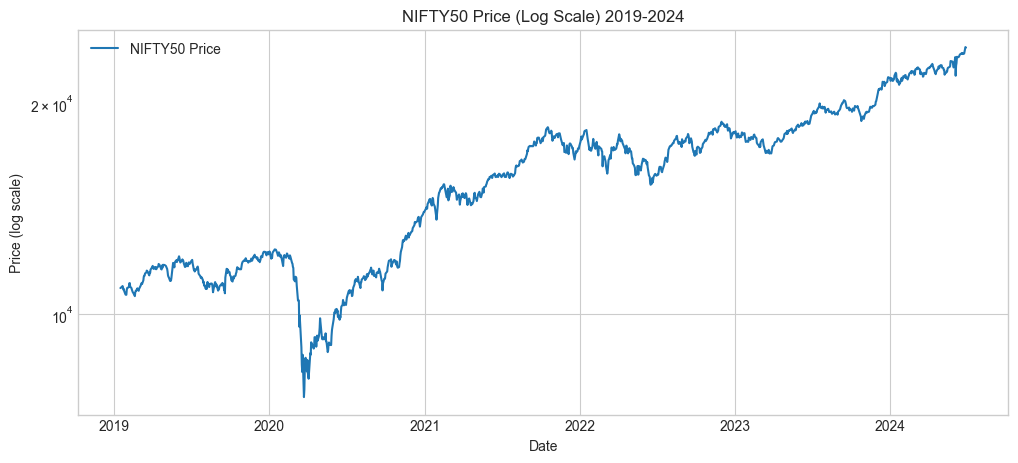

In [8]:
# Plot: NIFTY50 price series with log-scale y-axis
plt.figure(figsize=(12, 5))
plt.plot(prices_aligned[INDEX], label='NIFTY50 Price')
plt.yscale('log')
plt.title("NIFTY50 Price (Log Scale) 2019-2024")
plt.xlabel("Date")
plt.ylabel("Price (log scale)")
plt.legend()
plt.show()


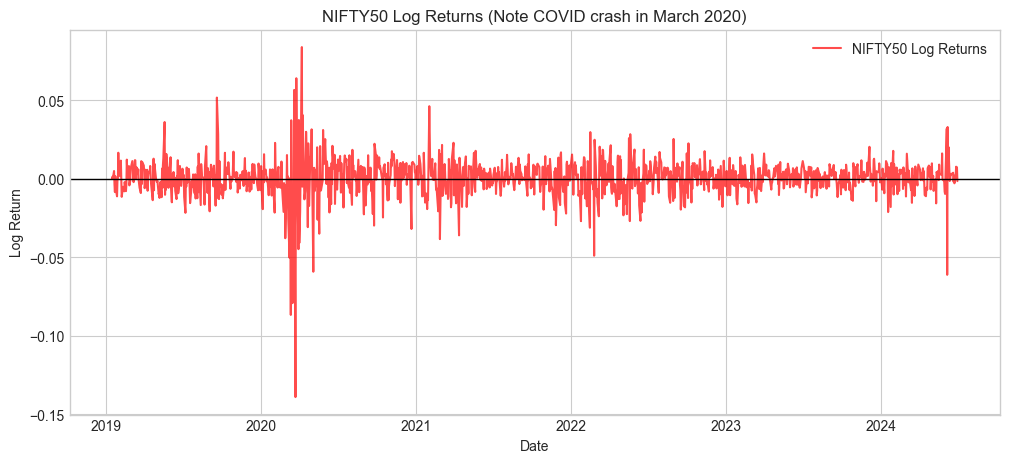

In [9]:
# Plot: NIFTY50 log returns as a time series
plt.figure(figsize=(12, 5))
plt.plot(log_returns[INDEX], color='red', alpha=0.7, label='NIFTY50 Log Returns')
plt.title("NIFTY50 Log Returns (Note COVID crash in March 2020)")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.axhline(0, color='black', lw=1)
plt.legend()
plt.show()


In [10]:
# Descriptive stats table (mean, std, skew, kurtosis)
def get_stats(df):
    stats = pd.DataFrame({
        'Mean (bps)': df.mean() * 10000,
        'Std Dev (%)': df.std() * 100,
        'Skewness': df.skew(),
        'Kurtosis': df.kurtosis()
    })
    return stats

ret_stats = get_stats(log_returns)
print("Descriptive Statistics for Log Returns:")
display(ret_stats)


Descriptive Statistics for Log Returns:


,Mean (bps),Std Dev (%),Skewness,Kurtosis
ASIANPAINT.NS,5.765075,1.636814,-0.433422,8.361816
AXISBANK.NS,4.863530,2.317788,-1.862888,35.223158
BAJAJ-AUTO.NS,10.594102,1.670452,-0.127822,9.771158
DRREDDY.NS,6.967415,1.600766,0.460235,8.106596
HDFCBANK.NS,3.803214,1.689593,-0.351597,9.432065
HINDUNILVR.NS,3.029595,1.472400,0.935306,10.266231
ICICIBANK.NS,8.842114,2.038430,-0.682988,11.949368
INFY.NS,6.782658,1.793379,-0.799686,12.472350
KOTAKBANK.NS,2.962862,1.837098,-0.426315,8.534506
LT.NS,7.968172,1.811532,-0.805054,11.990106


## 7. Save Parquet Files


In [11]:
os.makedirs('../data', exist_ok=True)
log_returns.to_parquet('../data/log_returns.parquet')
volatility.to_parquet('../data/volatility.parquet')
prices_aligned.to_parquet('../data/price_levels.parquet')

print("Saved log_returns.parquet, volatility.parquet, and price_levels.parquet to /data/")


Saved log_returns.parquet, volatility.parquet, and price_levels.parquet to /data/
